In [ ]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "README.md").is_file() and PROJECT_ROOT.parent != PROJECT_ROOT:
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "README.md").is_file():
    raise FileNotFoundError("Run this notebook from the project directory or one of its subdirectories.")


# EXP11 — Deep Learning Ensemble: iTransformer (EXP04) + PatchTST (EXP10)

iTransformer(변수 간 상관관계 기반)와 PatchTST(시간 패치 및 국소 파형 기반)의 OOF 예측치를 결합하여 대회 공식 지표($h_s \ge 1.5\text{m}$ 고파랑 통합 RMSE)를 최소화하는 리드타임별 최적 가중치 앙상블 파이프라인입니다.

### 파이프라인 구성
1. **데이터 및 OOF 로드**: `oof_exp04.csv`, `oof_exp10.csv`, `train_final_physics_v3.csv`
2. **개별 딥러닝 단독 성능 검증**: EXP04 vs EXP10 리드타임별/통합 고파랑 RMSE 벤치마크
3. **리드타임별 제약 최적화 (SLSQP)**: $w_{\text{itrans}} + w_{\text{patch}} = 1.0$
4. **앙상블 OOF 성능 평가 및 저장**: `oof_exp11.csv` 생성
5. **테스트셋 가중 앙상블 추론 및 최종 파일 저장**: `submission_exp11.csv` 생성

In [1]:
# ============================================================
# 0. SETUP & PACKAGES
# ============================================================
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
from scipy.optimize import minimize
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
print("Setup Complete for EXP11 Deep Ensemble (iTransformer + PatchTST).")

Setup Complete for EXP11 Deep Ensemble (iTransformer + PatchTST).


In [2]:
# ============================================================
# 1. CONFIG & FILE PATHS
# ============================================================
DATA_PATH = Path(PROJECT_ROOT / "data" / "processed" / "train_final_physics_v3.csv")
TEST_INDEX_PATH = Path(PROJECT_ROOT / "data" / "raw" / "test_index.csv")

# OOF 파일 경로
OOF_EXP04_PATH = Path(PROJECT_ROOT / "oof" / "oof_exp04.csv")  # iTransformer
OOF_EXP10_PATH = Path(PROJECT_ROOT / "oof" / "oof_exp10.csv")  # PatchTST

# Submission 파일 경로
SUB_EXP04_PATH = Path(PROJECT_ROOT / "submission" / "submission_exp04.csv")
SUB_EXP10_PATH = Path(PROJECT_ROOT / "submission" / "submission_exp10.csv")

# 산출물 경로
OOF_OUTPUT_PATH = Path(PROJECT_ROOT / "oof" / "oof_exp11.csv")
SUBMISSION_OUTPUT_PATH = Path(PROJECT_ROOT / "submission" / "submission_exp11.csv")

LEAD_HOURS = [3, 6, 9, 12, 18, 24]
STEPS_PER_HOUR = 6
STEP_MINUTES = 10
INPUT_LEN = 289
LEAD_STEPS = [h * STEPS_PER_HOUR for h in LEAD_HOURS]

print("Target Leads:", LEAD_HOURS)

Target Leads: [3, 6, 9, 12, 18, 24]


In [22]:
import numpy as np
import pandas as pd

# ============================================================
# 2. LOAD OOF PREDICTIONS & GROUND TRUTH (정확한 컬럼 매핑)
# ============================================================
oof_itrans = pd.read_csv(OOF_EXP04_PATH)
oof_patch  = pd.read_csv(OOF_EXP10_PATH)

N_VAL = len(oof_patch)  # 25,920
N_LEADS = len(LEAD_HOURS)  # 6

# 1. iTransformer (EXP04) 예측값: 롱 포맷의 'y_pred'만 추출하여 (25920, 6) 변환
p_itrans = oof_itrans["y_pred"].to_numpy(dtype=np.float32).reshape(N_VAL, N_LEADS)

# 2. PatchTST (EXP10) 예측값: y_pred_3h ~ y_pred_24h 컬럼 추출
patch_pred_cols = [f"y_pred_{h}h" for h in LEAD_HOURS]
p_patch = oof_patch[patch_pred_cols].to_numpy(dtype=np.float32)

# 3. Ground Truth (실제 정답) 및 고파랑(hs >= 1.5m) 마스크: EXP10 기준 추출
patch_true_cols = [f"y_true_{h}h" for h in LEAD_HOURS]
Y_true_arr = oof_patch[patch_true_cols].to_numpy(dtype=np.float32)

origin_hs_arr = oof_patch["origin_hs"].to_numpy(dtype=np.float32)
high_mask = origin_hs_arr >= 1.5

print("=" * 65)
print(f"★ 정렬 완료:")
print(f" - iTransformer(EXP04) 예측 행렬: {p_itrans.shape} (첫 샘플: {np.round(p_itrans[0, :3], 3)})")
print(f" - PatchTST(EXP10)     예측 행렬: {p_patch.shape} (첫 샘플: {np.round(p_patch[0, :3], 3)})")
print(f" - 실제 Ground Truth  정답 행렬: {Y_true_arr.shape} (첫 샘플: {np.round(Y_true_arr[0, :3], 3)})")
print(f" - 전체 검증 샘플: {N_VAL}개 | 고파랑(hs >= 1.5m) 검증 샘플: {high_mask.sum()}개")
print("=" * 65)

★ 정렬 완료:
 - iTransformer(EXP04) 예측 행렬: (25920, 6) (첫 샘플: [1.295 1.403 1.452])
 - PatchTST(EXP10)     예측 행렬: (25920, 6) (첫 샘플: [1.    1.083 1.247])
 - 실제 Ground Truth  정답 행렬: (25920, 6) (첫 샘플: [1.34 1.41 1.46])
 - 전체 검증 샘플: 25920개 | 고파랑(hs >= 1.5m) 검증 샘플: 1672개


In [23]:
import numpy as np
import pandas as pd

# ============================================================
# 2. LOAD OOF PREDICTIONS & GROUND TRUTH (정확한 컬럼 매핑)
# ============================================================
oof_itrans = pd.read_csv(OOF_EXP04_PATH)
oof_patch  = pd.read_csv(OOF_EXP10_PATH)

N_VAL = len(oof_patch)  # 25,920
N_LEADS = len(LEAD_HOURS)  # 6

# 1. iTransformer (EXP04) 예측값: 롱 포맷의 'y_pred'만 추출하여 (25920, 6) 변환
p_itrans = oof_itrans["y_pred"].to_numpy(dtype=np.float32).reshape(N_VAL, N_LEADS)

# 2. PatchTST (EXP10) 예측값: y_pred_3h ~ y_pred_24h 컬럼 추출
patch_pred_cols = [f"y_pred_{h}h" for h in LEAD_HOURS]
p_patch = oof_patch[patch_pred_cols].to_numpy(dtype=np.float32)

# 3. Ground Truth (실제 정답) 및 고파랑(hs >= 1.5m) 마스크: EXP10 기준 추출
patch_true_cols = [f"y_true_{h}h" for h in LEAD_HOURS]
Y_true_arr = oof_patch[patch_true_cols].to_numpy(dtype=np.float32)

origin_hs_arr = oof_patch["origin_hs"].to_numpy(dtype=np.float32)
high_mask = origin_hs_arr >= 1.5

print("=" * 65)
print(f"★ 정렬 완료:")
print(f" - iTransformer(EXP04) 예측 행렬: {p_itrans.shape} (첫 샘플: {np.round(p_itrans[0, :3], 3)})")
print(f" - PatchTST(EXP10)     예측 행렬: {p_patch.shape} (첫 샘플: {np.round(p_patch[0, :3], 3)})")
print(f" - 실제 Ground Truth  정답 행렬: {Y_true_arr.shape} (첫 샘플: {np.round(Y_true_arr[0, :3], 3)})")
print(f" - 전체 검증 샘플: {N_VAL}개 | 고파랑(hs >= 1.5m) 검증 샘플: {high_mask.sum()}개")
print("=" * 65)

★ 정렬 완료:
 - iTransformer(EXP04) 예측 행렬: (25920, 6) (첫 샘플: [1.295 1.403 1.452])
 - PatchTST(EXP10)     예측 행렬: (25920, 6) (첫 샘플: [1.    1.083 1.247])
 - 실제 Ground Truth  정답 행렬: (25920, 6) (첫 샘플: [1.34 1.41 1.46])
 - 전체 검증 샘플: 25920개 | 고파랑(hs >= 1.5m) 검증 샘플: 1672개


In [16]:
# ============================================================
# 3. SINGLE MODEL PERFORMANCE BENCHMARK
# ============================================================
def calc_rmse(y_true, y_pred):
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

def get_metrics(name, preds):
    high_true = Y_true_arr[high_mask]
    high_pred = preds[high_mask]
    res = {
        "Model": name,
        "Comp_Integrated_RMSE": calc_rmse(high_true, high_pred),
        "Overall_RMSE": calc_rmse(Y_true_arr, preds)
    }
    for idx, h in enumerate(LEAD_HOURS):
        res[f"Comp_{h}h"] = calc_rmse(high_true[:, idx], high_pred[:, idx])
    return res

bm_df = pd.DataFrame([
    get_metrics("EXP04 (iTransformer)", p_itrans),
    get_metrics("EXP10 (PatchTST)", p_patch),
    get_metrics("Simple Average (1:1)", (p_itrans + p_patch) / 2.0)
])

print("\n===== SINGLE MODEL BASELINE OOF METRICS =====")
display(bm_df)


===== SINGLE MODEL BASELINE OOF METRICS =====


,Model,Comp_Integrated_RMSE,Overall_RMSE,Comp_3h,Comp_6h,Comp_9h,Comp_12h,Comp_18h,Comp_24h
0,EXP04 (iTransformer),0.523424,0.347013,0.374186,0.447654,0.484200,0.546604,0.590989,0.648794
1,EXP10 (PatchTST),0.519803,0.359695,0.416530,0.490899,0.511999,0.561255,0.554579,0.567439
2,Simple Average (1:1),0.489329,0.335833,0.362264,0.433804,0.459308,0.521483,0.544287,0.581448


In [17]:
# ============================================================
# 4. HORIZON-WISE OPTIMAL WEIGHT SEARCH (SLSQP)
# ============================================================
optimal_weights = {}
blend_oof_preds = np.zeros_like(Y_true_arr)

print("\nStarting Horizon-wise Optimization for hs >= 1.5m RMSE...\n")

for idx, h in enumerate(LEAD_HOURS):
    c_it = p_itrans[:, idx]
    c_pt = p_patch[:, idx]
    y_tr = Y_true_arr[:, idx]

    # 목적함수: 기준시점 hs >= 1.5m 고파랑 샘플의 RMSE 최소화
    def obj(w):
        pred = w[0] * c_it + w[1] * c_pt
        return calc_rmse(y_tr[high_mask], pred[high_mask])

    res = minimize(
        obj,
        [0.5, 0.5],
        method='SLSQP',
        bounds=[(0.0, 1.0), (0.0, 1.0)],
        constraints=({'type': 'eq', 'fun': lambda w: sum(w) - 1.0})
    )

    w_it, w_pt = res.x
    optimal_weights[h] = (w_it, w_pt)
    blend_oof_preds[:, idx] = w_it * c_it + w_pt * c_pt

    print(f"Lead +{h:02d}h -> iTransformer: {w_it:.4f}, PatchTST: {w_pt:.4f} | Lead High-RMSE: {res.fun:.5f}")

# 전체 6개 리드타임 공식 통합 RMSE 계산
y_true_high = Y_true_arr[high_mask]
y_pred_high = blend_oof_preds[high_mask]
final_comp_rmse = calc_rmse(y_true_high, y_pred_high)
final_overall_rmse = calc_rmse(Y_true_arr, blend_oof_preds)

print("\n" + "=" * 75)
print(f"★ EXP11 BLENDED INTEGRATED HIGH-WAVE RMSE: {final_comp_rmse:.5f} m")
print(f"★ EXP11 BLENDED OVERALL RMSE:             {final_overall_rmse:.5f} m")
print("=" * 75)


Starting Horizon-wise Optimization for hs >= 1.5m RMSE...

Lead +03h -> iTransformer: 0.6644, PatchTST: 0.3356 | Lead High-RMSE: 0.35845
Lead +06h -> iTransformer: 0.6564, PatchTST: 0.3436 | Lead High-RMSE: 0.43014
Lead +09h -> iTransformer: 0.5928, PatchTST: 0.4072 | Lead High-RMSE: 0.45791
Lead +12h -> iTransformer: 0.5581, PatchTST: 0.4419 | Lead High-RMSE: 0.52103
Lead +18h -> iTransformer: 0.3375, PatchTST: 0.6625 | Lead High-RMSE: 0.54117
Lead +24h -> iTransformer: 0.1295, PatchTST: 0.8705 | Lead High-RMSE: 0.56546

★ EXP11 BLENDED INTEGRATED HIGH-WAVE RMSE: 0.48430 m
★ EXP11 BLENDED OVERALL RMSE:             0.33755 m


In [18]:
# ============================================================
# 5. SAVE EXP11 OOF PREDICTIONS
# ============================================================
oof_exp11_df = pd.DataFrame(blend_oof_preds, columns=[f"pred_{h}h" for h in LEAD_HOURS])
oof_exp11_df["origin_hs"] = origin_hs_arr
if "origin_time" in oof_itrans.columns:
    oof_exp11_df["origin_time"] = oof_itrans["origin_time"]

oof_exp11_df.to_csv(OOF_OUTPUT_PATH, index=False)
print(f"Saved Blended OOF: {OOF_OUTPUT_PATH}")

Saved Blended OOF: oof_exp11.csv


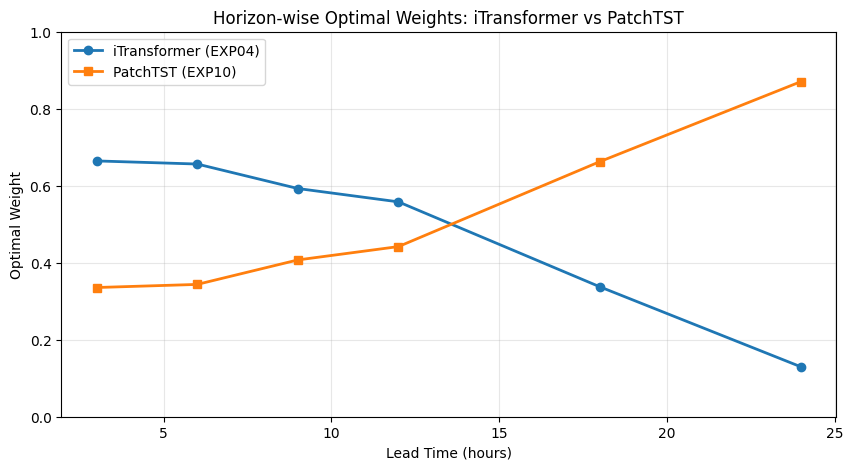

In [19]:
# ============================================================
# 6. PLOT WEIGHTS ACROSS LEAD TIMES
# ============================================================
weights_df = pd.DataFrame(optimal_weights, index=["iTransformer (EXP04)", "PatchTST (EXP10)"]).T

plt.figure(figsize=(10, 5))
plt.plot(weights_df.index, weights_df["iTransformer (EXP04)"], marker='o', label="iTransformer (EXP04)", color="#1f77b4", linewidth=2)
plt.plot(weights_df.index, weights_df["PatchTST (EXP10)"], marker='s', label="PatchTST (EXP10)", color="#ff7f0e", linewidth=2)
plt.xlabel("Lead Time (hours)")
plt.ylabel("Optimal Weight")
plt.title("Horizon-wise Optimal Weights: iTransformer vs PatchTST")
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [20]:
# ============================================================
# 7. APPLY OPTIMAL WEIGHTS TO TEST SET (CREATE EXP11 SUBMISSION)
# ============================================================
print("Applying Optimal Weights to Test Predictions...")

sub_itrans = pd.read_csv(SUB_EXP04_PATH)
sub_patch  = pd.read_csv(SUB_EXP10_PATH)

sub_final = sub_itrans.copy()
sub_final["hs_pred"] = 0.0

for h in LEAD_HOURS:
    w_it, w_pt = optimal_weights[h]
    mask = sub_final["lead_h"] == h

    sub_final.loc[mask, "hs_pred"] = (
        w_it * sub_itrans.loc[mask, "hs_pred"] +
        w_pt * sub_patch.loc[mask, "hs_pred"]
    )

# 물리적 상/하한 클리핑
sub_final["hs_pred"] = sub_final["hs_pred"].clip(lower=0.01, upper=30.0)
sub_final.to_csv(SUBMISSION_OUTPUT_PATH, index=False, encoding="utf-8")

print("=" * 80)
print(f"EXP11 FINAL ENSEMBLE SUBMISSION SAVED: {SUBMISSION_OUTPUT_PATH}")
print("=" * 80)
print("\nPrediction Stats:")
display(sub_final["hs_pred"].describe())
display(sub_final.head(12))

Applying Optimal Weights to Test Predictions...
EXP11 FINAL ENSEMBLE SUBMISSION SAVED: submission_exp11.csv

Prediction Stats:


,hs_pred
count,1200.000000
mean,1.575203
std,0.446316
min,0.654415
25%,1.266812
50%,1.511900
75%,1.799765
max,3.992920


,case_id,station,lead_h,hs_pred
0,C0001,S-ORS,3,1.519182
1,C0001,S-ORS,6,1.391339
2,C0001,S-ORS,9,1.462216
3,C0001,S-ORS,12,1.507266
4,C0001,S-ORS,18,1.464132
5,C0001,S-ORS,24,1.492338
6,C0002,I-ORS,3,1.462786
7,C0002,I-ORS,6,1.447081
8,C0002,I-ORS,9,1.513691
9,C0002,I-ORS,12,1.428021
